# Crime Arrest Data Analysis

Domain: Public Safety / Crime Analytics

Objective: Analyze arrest records to identify demographic trends, crime patterns, geographic hotspots, and temporal trends using Python-based exploratory data analysis and visualization techniques.

1.Law enforcement agencies collect large volumes of arrest data.

2.Raw records contain missing values, inconsistent formats, and redundant information.

3.Goal is to preprocess the data and uncover patterns related to age, gender, area, time, and charge categories.

Dataset details:

Source: Los Angeles Open Data

Records: ~70,000

Columns: 24

Mixed numerical, categorical, and temporal features.

This project uses a real-world arrest dataset from Los Angeles containing approximately 70,000 arrest records with 24 features, including demographic information, arrest details, geographic coordinates, and booking information.



# Importing the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

print('Libraries imported successfully')

Libraries imported successfully


# Load dataset


In [2]:
df = pd.read_csv('C:/Users/malav/Downloads/Crime data.csv')

# Display first 5 rows
df.head()

,Report ID,Report Type,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Disposition Description,Address,Cross Street,LAT,LON,Location,Booking Date,Booking Time,Booking Location,Booking Location Code
0,240204105,RFC,2024 Jan 03 12:00:00 AM,1815.0,2,Rampart,246,31,M,B,24.0,Miscellaneous Other Violations,M,369I(B)1PC,ENTER RAILROAD PROPERTY HINDER OPERATION,NaN,600 S ALVARADO ST,NaN,34.0595,-118.2749,POINT (-118.2749 34.0595),NaN,NaN,NaN,NaN
1,6737155,BOOKING,2024 Jan 04 12:00:00 AM,1220.0,5,Harbor,503,2,F,B,NaN,NaN,D,300WI,NaN,NaN,1000 HARBOR HEIGH DR,NaN,33.7941,-118.2900,POINT (-118.29 33.7941),2024 Jan 04 12:00:00 AM,1641.0,HARBOR,4205.0
2,240104425,RFC,2024 Jan 06 12:00:00 AM,1505.0,1,Central,119,26,M,H,NaN,NaN,M,369I(B)(1)P,NaN,NaN,800 N ALAMEDA ST,NaN,34.0561,-118.2375,POINT (-118.2375 34.0561),NaN,NaN,NaN,NaN
3,240904035,RFC,2024 Jan 02 12:00:00 AM,1320.0,9,Van Nuys,964,39,M,O,NaN,NaN,M,4595,NaN,MISDEMEANOR COMPLAINT FILED,14000 RIVERSIDE DR,NaN,34.1576,-118.4387,POINT (-118.4387 34.1576),NaN,NaN,NaN,NaN
4,240104266,RFC,2024 Jan 04 12:00:00 AM,1810.0,1,Central,153,38,M,W,NaN,NaN,M,369I(B)(1)P,NaN,MISDEMEANOR COMPLAINT FILED,500 S HILL ST,NaN,34.0488,-118.2518,POINT (-118.2518 34.0488),NaN,NaN,NaN,NaN


Number of rows and columns

In [3]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 70189
Columns: 25


Column names

In [4]:
df.columns

Index(['Report ID', 'Report Type', 'Arrest Date', 'Time', 'Area ID',
       'Area Name', 'Reporting District', 'Age', 'Sex Code', 'Descent Code',
       'Charge Group Code', 'Charge Group Description', 'Arrest Type Code',
       'Charge', 'Charge Description', 'Disposition Description', 'Address',
       'Cross Street', 'LAT', 'LON', 'Location', 'Booking Date',
       'Booking Time', 'Booking Location', 'Booking Location Code'],
      dtype='object')

Data types

In [5]:
df.dtypes

Report ID                     int64
Report Type                  object
Arrest Date                  object
Time                        float64
Area ID                       int64
Area Name                    object
Reporting District            int64
Age                           int64
Sex Code                     object
Descent Code                 object
Charge Group Code           float64
Charge Group Description     object
Arrest Type Code             object
Charge                       object
Charge Description           object
Disposition Description      object
Address                      object
Cross Street                 object
LAT                         float64
LON                         float64
Location                     object
Booking Date                 object
Booking Time                float64
Booking Location             object
Booking Location Code       float64
dtype: object

Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70189 entries, 0 to 70188
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Report ID                 70189 non-null  int64  
 1   Report Type               70189 non-null  object 
 2   Arrest Date               70189 non-null  object 
 3   Time                      70183 non-null  float64
 4   Area ID                   70189 non-null  int64  
 5   Area Name                 70189 non-null  object 
 6   Reporting District        70189 non-null  int64  
 7   Age                       70189 non-null  int64  
 8   Sex Code                  70189 non-null  object 
 9   Descent Code              70189 non-null  object 
 10  Charge Group Code         59902 non-null  float64
 11  Charge Group Description  59895 non-null  object 
 12  Arrest Type Code          70188 non-null  object 
 13  Charge                    70189 non-null  object 
 14  Charge

Statistical summary

In [7]:
df.describe(include='all')

,Report ID,Report Type,Arrest Date,Time,Area ID,Area Name,Reporting District,Age,Sex Code,Descent Code,Charge Group Code,Charge Group Description,Arrest Type Code,Charge,Charge Description,Disposition Description,Address,Cross Street,LAT,LON,Location,Booking Date,Booking Time,Booking Location,Booking Location Code
count,7.018900e+04,70189,70189,70183.000000,70189.000000,70189,70189.000000,70189.000000,70189,70189,59902.000000,59895,70188,70189,59902,60729,70189,26239,70189.000000,70189.000000,70189,50242,50242.000000,50234,50242.000000
unique,NaN,2,366,NaN,NaN,21,NaN,NaN,2,14,NaN,27,6,2162,870,19,16404,4260,NaN,NaN,16854,373,NaN,21,NaN
top,NaN,BOOKING,2024 Aug 09 12:00:00 AM,NaN,NaN,Central,NaN,NaN,M,H,NaN,Miscellaneous Other Violations,M,273.5(A)PC,CORPORAL INJURY ON SPOUSE/COHABITANT/ETC,MISDEMEANOR COMPLAINT FILED,2200 W 6TH ST,FIGUEROA,NaN,NaN,POINT (-118.2761 34.0601),2024 May 02 12:00:00 AM,NaN,METRO - JAIL DIVISION,NaN
freq,NaN,50242,291,NaN,NaN,8516,NaN,NaN,56187,35413,NaN,9748,33025,3627,3627,35264,1611,439,NaN,NaN,1656,221,NaN,16364,NaN
mean,7.335202e+07,NaN,NaN,1322.320291,9.711465,NaN,1017.280842,35.737067,NaN,NaN,13.279523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.075665,-118.329851,NaN,NaN,1275.210382,NaN,4252.735779
std,1.055626e+08,NaN,NaN,626.007621,6.523607,NaN,652.631127,12.252392,NaN,NaN,7.661001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.355334,1.186173,NaN,NaN,729.797476,NaN,31.272047
min,6.449673e+06,NaN,NaN,1.000000,1.000000,NaN,101.000000,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-118.666600,NaN,NaN,1.000000,NaN,4201.000000
25%,6.806410e+06,NaN,NaN,900.000000,3.000000,NaN,356.000000,27.000000,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.027300,-118.409400,NaN,NaN,559.000000,NaN,4212.000000
50%,6.883489e+06,NaN,NaN,1358.000000,10.000000,NaN,1015.000000,34.000000,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.059500,-118.302200,NaN,NaN,1359.000000,NaN,4273.000000
75%,2.401168e+08,NaN,NaN,1825.000000,15.000000,NaN,1549.000000,43.000000,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.168400,-118.268900,NaN,NaN,1928.000000,NaN,4279.000000


# Initial observations



1.Date columns are stored as text.

2.Several categorical columns contain missing values.

3.Geographic coordinates are available.

4.Time is stored as HHMM integer format.

# Data Cleaning & Pre-processing

1.Remove Duplicates

In [8]:
print('Duplicate rows:', df.duplicated().sum())

df = df.drop_duplicates()

print('After removing duplicates:', df.shape)

Duplicate rows: 0
After removing duplicates: (70189, 25)


2.Convert Date Columns

In [9]:
df['Arrest Date'] = pd.to_datetime(df['Arrest Date'], errors='coerce')
df['Booking Date'] = pd.to_datetime(df['Booking Date'], errors='coerce')

df[['Arrest Date', 'Booking Date']].head()

,Arrest Date,Booking Date
0,2024-01-03,NaT
1,2024-01-04,2024-01-04
2,2024-01-06,NaT
3,2024-01-02,NaT
4,2024-01-04,NaT


3.Handle Missing Values

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Cross Street                43950
Booking Location            19955
Booking Location Code       19947
Booking Time                19947
Booking Date                19947
Charge Group Description    10294
Charge Group Code           10287
Charge Description          10287
Disposition Description      9460
Time                            6
Arrest Type Code                1
dtype: int64

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

Cross Street                62.616649
Booking Location            28.430381
Booking Location Code       28.418983
Booking Time                28.418983
Booking Date                28.418983
Charge Group Description    14.666116
Charge Group Code           14.656143
Charge Description          14.656143
Disposition Description     13.477895
Time                         0.008548
Arrest Type Code             0.001425
Descent Code                 0.000000
Report Type                  0.000000
Charge                       0.000000
Sex Code                     0.000000
Age                          0.000000
Address                      0.000000
Reporting District           0.000000
LAT                          0.000000
LON                          0.000000
Location                     0.000000
Area Name                    0.000000
Area ID                      0.000000
Arrest Date                  0.000000
Report ID                    0.000000
dtype: float64

Fill important categorical columns.

In [12]:
cat_cols = ['Sex Code', 'Descent Code', 'Charge Group Description',
            'Charge Description', 'Disposition Description',
            'Booking Location']

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

Fill numerical values.

In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

4.Rename Columns

In [14]:
df.columns = df.columns.str.replace(' ', '_')

df.columns

Index(['Report_ID', 'Report_Type', 'Arrest_Date', 'Time', 'Area_ID',
       'Area_Name', 'Reporting_District', 'Age', 'Sex_Code', 'Descent_Code',
       'Charge_Group_Code', 'Charge_Group_Description', 'Arrest_Type_Code',
       'Charge', 'Charge_Description', 'Disposition_Description', 'Address',
       'Cross_Street', 'LAT', 'LON', 'Location', 'Booking_Date',
       'Booking_Time', 'Booking_Location', 'Booking_Location_Code'],
      dtype='object')

5.Remove Unnecessary Columns

In [15]:
df = df.drop(columns=['Location'], errors='ignore')

NB:The Location column was removed because latitude and longitude provide the same information in a more usable numerical format.

6.Create Derived Features

Arrest Year

In [16]:
df['Arrest_Year'] = df['Arrest_Date'].dt.year

Arrest Month

In [17]:
df['Arrest_Month'] = df['Arrest_Date'].dt.month_name()

Arrest Day

In [18]:
df['Arrest_Day'] = df['Arrest_Date'].dt.day_name()

Arrest Hour

In [19]:
df['Time'].head(20)

0     1815.0
1     1220.0
2     1505.0
3     1320.0
4     1810.0
5     2000.0
6     1810.0
7      730.0
8     1230.0
9      351.0
10     930.0
11    1500.0
12    1220.0
13    1215.0
14     830.0
15    1400.0
16    1015.0
17    1200.0
18    1430.0
19    1415.0
Name: Time, dtype: float64

In [20]:
df['Time'].unique()[:20]

array([1815., 1220., 1505., 1320., 1810., 2000.,  730., 1230.,  351.,
        930., 1500., 1215.,  830., 1400., 1015., 1200., 1430., 1415.,
       1355.,  735.])

Check Data type

In [21]:
df['Time'].dtype

dtype('float64')

Find the problematic values

In [22]:
df[~df['Time'].astype(str).str.match(r'^\d+$', na=False)]['Time'].unique()

array([1815., 1220., 1505., ..., 1109., 1943.,  418.])

In [23]:
# Convert Time to numeric, invalid values become NaN
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')

# Fill missing values with 0
df['Time'] = df['Time'].fillna(0).astype(int)

# Convert to 4-digit string
df['Time'] = df['Time'].astype(str).str.zfill(4)

# Extract hour
df['Arrest_Hour'] = df['Time'].str[:2].astype(int)

df[['Time', 'Arrest_Hour']].head()

,Time,Arrest_Hour
0,1815,18
1,1220,12
2,1505,15
3,1320,13
4,1810,18


In [24]:
df[['Time', 'Arrest_Hour']].sample(10)

,Time,Arrest_Hour
33619,1635,16
29699,0740,7
64089,0420,4
27804,1020,10
41321,0815,8
66137,0015,0
24381,0830,8
37733,1835,18
30269,2324,23
51361,0725,7


# Exploratory Data Analysis (EDA)

In [25]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 70189
Columns: 28


In [26]:
df.nunique().sort_values(ascending=False)

Report_ID                   70189
Address                     16404
Cross_Street                 4260
LAT                          3842
LON                          3768
Charge                       2162
Booking_Time                 1437
Time                         1413
Reporting_District           1186
Charge_Description            871
Booking_Date                  373
Arrest_Date                   366
Age                            93
Charge_Group_Code              28
Charge_Group_Description       28
Booking_Location_Code          24
Arrest_Hour                    24
Booking_Location               22
Area_Name                      21
Area_ID                        21
Disposition_Description        20
Descent_Code                   14
Arrest_Month                   12
Arrest_Day                      7
Arrest_Type_Code                6
Sex_Code                        2
Report_Type                     2
Arrest_Year                     1
dtype: int64

In [27]:
print("Report Types:", df['Report_Type'].unique())
print("Sex Codes:", df['Sex_Code'].unique())
print("Area Names:", df['Area_Name'].nunique())
print("Charge Groups:", df['Charge_Group_Description'].nunique())

Report Types: ['RFC' 'BOOKING']
Sex Codes: ['M' 'F']
Area Names: 21
Charge Groups: 28


Summary Statistics

In [28]:
df.describe()

,Report_ID,Area_ID,Reporting_District,Age,Charge_Group_Code,LAT,LON,Booking_Time,Booking_Location_Code,Arrest_Year,Arrest_Hour
count,7.018900e+04,70189.000000,70189.000000,70189.000000,59902.000000,70189.000000,70189.000000,50242.000000,50242.000000,70189.0,70189.000000
mean,7.335202e+07,9.711465,1017.280842,35.737067,13.279523,34.075665,-118.329851,1275.210382,4252.735779,2024.0,12.974227
std,1.055626e+08,6.523607,652.631127,12.252392,7.661001,0.355334,1.186173,729.797476,31.272047,0.0,6.262661
min,6.449673e+06,1.000000,101.000000,0.000000,1.000000,0.000000,-118.666600,1.000000,4201.000000,2024.0,0.000000
25%,6.806410e+06,3.000000,356.000000,27.000000,6.000000,34.027300,-118.409400,559.000000,4212.000000,2024.0,9.000000
50%,6.883489e+06,10.000000,1015.000000,34.000000,12.000000,34.059500,-118.302200,1359.000000,4273.000000,2024.0,13.000000
75%,2.401168e+08,15.000000,1549.000000,43.000000,22.000000,34.168400,-118.268900,1928.000000,4279.000000,2024.0,18.000000
max,2.520040e+08,21.000000,2197.000000,94.000000,29.000000,34.327500,0.000000,2359.000000,4279.000000,2024.0,23.000000


In [29]:
df.describe(include='object')

,Report_Type,Time,Area_Name,Sex_Code,Descent_Code,Charge_Group_Description,Arrest_Type_Code,Charge,Charge_Description,Disposition_Description,Address,Cross_Street,Booking_Location,Arrest_Month,Arrest_Day
count,70189,70189,70189,70189,70189,70189,70188,70189,70189,70189,70189,26239,70189,70189,70189
unique,2,1413,21,2,14,28,6,2162,871,20,16404,4260,22,12,7
top,BOOKING,1500,Central,M,H,Unknown,M,273.5(A)PC,Unknown,MISDEMEANOR COMPLAINT FILED,2200 W 6TH ST,FIGUEROA,Unknown,August,Thursday
freq,50242,826,8516,56187,35413,10294,33025,3627,10287,35264,1611,439,19955,7149,10910


Top 10 Arrest Areas

In [30]:
df['Area_Name'].value_counts().head(10)

Central        8516
Rampart        7305
N Hollywood    4111
Southwest      3920
77th Street    3763
Newton         3744
Hollywood      3615
Van Nuys       3494
Olympic        3189
Southeast      2900
Name: Area_Name, dtype: int64

Top Charge Categories

In [31]:
df['Charge_Group_Description'].value_counts().head(10)

Unknown                           10294
Miscellaneous Other Violations     9748
Aggravated Assault                 8144
Other Assaults                     5857
Narcotic Drug Laws                 5805
Driving Under Influence            5372
Larceny                            4397
Weapon (carry/poss)                4001
Vehicle Theft                      2570
Robbery                            2288
Name: Charge_Group_Description, dtype: int64

Arrests by Gender

In [32]:
df['Sex_Code'].value_counts()

M    56187
F    14002
Name: Sex_Code, dtype: int64

Arrest Type

In [33]:
df['Arrest_Type_Code'].value_counts()

M    33025
F    29479
I     6760
O      483
D      439
1        2
Name: Arrest_Type_Code, dtype: int64

# GroupBy Analysis

Arrests by Area

In [34]:
area_counts = df.groupby('Area_Name').size().sort_values(ascending=False)

area_counts.head(10)

Area_Name
Central        8516
Rampart        7305
N Hollywood    4111
Southwest      3920
77th Street    3763
Newton         3744
Hollywood      3615
Van Nuys       3494
Olympic        3189
Southeast      2900
dtype: int64

Average Age by Gender

In [35]:
df.groupby('Sex_Code')['Age'].mean().round().astype(int)

Sex_Code
F    34
M    36
Name: Age, dtype: int32

Average Age by Area

In [36]:
df.groupby('Area_Name')['Age'].mean().sort_values(ascending=False).astype(int)

Area_Name
Pacific        38
Devonshire     37
West LA        37
Northeast      37
Central        36
Topanga        36
Foothill       36
N Hollywood    36
Wilshire       36
Harbor         36
Rampart        35
West Valley    35
Mission        35
Southwest      35
Van Nuys       34
Hollywood      34
Newton         34
77th Street    33
Olympic        33
Hollenbeck     33
Southeast      33
Name: Age, dtype: int32

Arrests by Month

In [37]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['Arrest_Month'] = pd.Categorical(
    df['Arrest_Month'],
    categories=month_order,
    ordered=True
)

df.groupby('Arrest_Month').size()

Arrest_Month
January      5710
February     4938
March        5616
April        5280
May          5766
June         5538
July         6125
August       7149
September    6821
October      6280
November     5813
December     5153
dtype: int64

Arrests by Hour

In [38]:
df.groupby('Arrest_Hour').size()

Arrest_Hour
0     2198
1     1908
2     1718
3     1350
4      959
5      726
6     2004
7     3013
8     3369
9     3666
10    3732
11    3469
12    3560
13    3432
14    4305
15    4107
16    3912
17    3591
18    3338
19    3121
20    3335
21    3095
22    3143
23    3138
dtype: int64

# Pivot Table Analysis

Average Age by Gender and Arrest Type

In [39]:
pivot_age = pd.pivot_table(
    df,
    values='Age',
    index='Sex_Code',
    columns='Arrest_Type_Code',
    aggfunc='mean'
)

pivot_age = pivot_age.round().astype('Int64')

pivot_age

Arrest_Type_Code,1,D,F,I,M,O
Sex_Code,,,,,,
F,<NA>,9,34,38,35,17
M,34,7,35,40,37,33


Arrest Count by Area and Gender

In [40]:
pivot_area = pd.pivot_table(
    df,
    values='Report_ID',
    index='Area_Name',
    columns='Sex_Code',
    aggfunc='count',
    fill_value=0
)

pivot_area.head()

Sex_Code,F,M
Area_Name,,
77th Street,868,2895
Central,1529,6987
Devonshire,619,1945
Foothill,442,2068
Harbor,386,1441


# Crosstab Analysis

Gender vs Arrest Type

In [41]:
pd.crosstab(df['Sex_Code'], df['Arrest_Type_Code'])

Arrest_Type_Code,1,D,F,I,M,O
Sex_Code,,,,,,
F,0,235,5072,1115,7497,83
M,2,204,24407,5645,25528,400


Area vs Report Type

In [42]:
pd.crosstab(df['Area_Name'], df['Report_Type'])

Report_Type,BOOKING,RFC
Area_Name,,
77th Street,3540,223
Central,4632,3884
Devonshire,1723,841
Foothill,2193,317
Harbor,1584,243
Hollenbeck,1883,400
Hollywood,2853,762
Mission,1956,625
N Hollywood,2721,1390


# Correlation Analysis

Select only numerical columns.

In [43]:
num_df = df.select_dtypes(include=['int64', 'float64'])

corr = num_df.corr()

corr

,Report_ID,Area_ID,Reporting_District,Age,Charge_Group_Code,LAT,LON,Booking_Time,Booking_Location_Code,Arrest_Year
Report_ID,1.000000,-0.137850,-0.139319,0.088585,0.177585,0.012998,-0.001094,0.001861,0.007310,NaN
Area_ID,-0.137850,1.000000,0.999247,-0.012390,-0.003125,0.100676,-0.047645,0.014983,0.057764,NaN
Reporting_District,-0.139319,0.999247,1.000000,-0.011596,-0.003342,0.099659,-0.047618,0.015247,0.055606,NaN
Age,0.088585,-0.012390,-0.011596,1.000000,0.050324,0.005451,-0.002671,0.037227,0.032116,NaN
Charge_Group_Code,0.177585,-0.003125,-0.003342,0.050324,1.000000,0.006722,0.003922,-0.030918,0.062765,NaN
LAT,0.012998,0.100676,0.099659,0.005451,0.006722,1.000000,-0.969217,-0.004975,0.165392,NaN
LON,-0.001094,-0.047645,-0.047618,-0.002671,0.003922,-0.969217,1.000000,0.001954,-0.021599,NaN
Booking_Time,0.001861,0.014983,0.015247,0.037227,-0.030918,-0.004975,0.001954,1.000000,-0.008511,NaN
Booking_Location_Code,0.007310,0.057764,0.055606,0.032116,0.062765,0.165392,-0.021599,-0.008511,1.000000,NaN
Arrest_Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This will later be used to create the heatmap.

Oldest Person Arrested

In [44]:
df.nlargest(5, 'Age')[['Age', 'Area_Name', 'Charge_Group_Description']]

,Age,Area_Name,Charge_Group_Description
66163,94,Central,Miscellaneous Other Violations
16032,93,Central,Unknown
40771,93,Wilshire,Larceny
46280,90,Olympic,Miscellaneous Other Violations
34661,89,Northeast,Against Family/Child


Youngest Person Arrested

In [45]:
df.nsmallest(5, 'Age')[['Age', 'Area_Name', 'Charge_Group_Description']]

,Age,Area_Name,Charge_Group_Description
582,0,Harbor,Unknown
937,0,Mission,Unknown
2902,0,Wilshire,Non-Criminal Detention
3527,0,West Valley,Unknown
3594,0,Newton,Unknown


In [46]:
(df['Age'] == 0).sum()

42

In [47]:
zero_age = (df['Age'] == 0).sum()

print("Age = 0 records:", zero_age)
print("Percentage:", round((zero_age / len(df)) * 100, 2), "%")

Age = 0 records: 42
Percentage: 0.06 %


In [48]:
df = df[df['Age'] > 0]

In [49]:
print("Age = 0 records:", (df['Age'] == 0).sum())
print("New dataset shape:", df.shape)

Age = 0 records: 0
New dataset shape: (70147, 28)


NB:Records with Age = 0 were removed because they likely represent missing or invalid age values rather than actual ages.

In [50]:
df.nsmallest(10, 'Age')[['Age', 'Area_Name', 'Charge_Group_Description']]

,Age,Area_Name,Charge_Group_Description
199,1,Pacific,Unknown
4997,1,Central,Non-Criminal Detention
8591,1,Foothill,Unknown
9513,1,Topanga,Non-Criminal Detention
16623,1,Southwest,Unknown
18547,1,Southwest,Unknown
19216,1,Southwest,Unknown
23944,1,Southeast,Unknown
25809,1,Topanga,Non-Criminal Detention
26791,1,Topanga,Non-Criminal Detention


Areas with Maximum Arrests

In [51]:
df['Area_Name'].value_counts().head(10)

Central        8515
Rampart        7304
N Hollywood    4110
Southwest      3918
77th Street    3762
Newton         3741
Hollywood      3613
Van Nuys       3493
Olympic        3187
Southeast      2896
Name: Area_Name, dtype: int64

Most Common Charges

In [52]:
df['Charge_Group_Description'].value_counts().head(10)

Unknown                           10265
Miscellaneous Other Violations     9748
Aggravated Assault                 8144
Other Assaults                     5857
Narcotic Drug Laws                 5805
Driving Under Influence            5372
Larceny                            4397
Weapon (carry/poss)                4001
Vehicle Theft                      2570
Robbery                            2288
Name: Charge_Group_Description, dtype: int64

# Outlier Detection

In [53]:
df['Age'].describe()

count    70147.000000
mean        35.758464
std         12.224805
min          1.000000
25%         27.000000
50%         34.000000
75%         43.000000
max         94.000000
Name: Age, dtype: float64

In [54]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 929


# Missing Value Verification

In [55]:
df.isnull().sum()

Report_ID                       0
Report_Type                     0
Arrest_Date                     0
Time                            0
Area_ID                         0
Area_Name                       0
Reporting_District              0
Age                             0
Sex_Code                        0
Descent_Code                    0
Charge_Group_Code           10258
Charge_Group_Description        0
Arrest_Type_Code                1
Charge                          0
Charge_Description              0
Disposition_Description         0
Address                         0
Cross_Street                43920
LAT                             0
LON                             0
Booking_Date                19946
Booking_Time                19946
Booking_Location                0
Booking_Location_Code       19946
Arrest_Year                     0
Arrest_Month                    0
Arrest_Day                      0
Arrest_Hour                     0
dtype: int64

1. Cross_Street

Over 43,000 values are missing. This is likely because many arrest records simply do not have a cross street recorded.

You don't need this column for your EDA, so it's acceptable to leave it as is or even drop it if you don't plan to use it.

In [56]:
df = df.drop(columns=['Cross_Street'])

2. Booking_Date, Booking_Time, Booking_Location_Code

These fields are missing together because not every arrest results in a bookings.

Therefore, do not fill these with fake values. Leaving them as NaN is appropriate

3. Arrest_Type_Code

There is only 1 missing value. Fill it with the most frequent value (mode):

In [57]:
df['Arrest_Type_Code'].fillna(df['Arrest_Type_Code'].mode()[0], inplace=True)

In [58]:
df.drop(columns=['Charge_Group_Code'], inplace=True)

Since you'll likely use Charge_Group_Description instead of Charge_Group_Code for your analysis and visualizations
Drop the column if you don't use it.

During preprocessing, missing values in important categorical fields (such as Sex Code, Charge Description, and Disposition Description) were replaced with "Unknown". Columns such as Booking Date, Booking Time, and Booking Location Code were intentionally left with missing values because they are only applicable to records involving a booking. Similarly, Cross Street contained a large proportion of missing values and was excluded from further analysis since it was not essential to the project objectives.

In [59]:
df.isnull().sum()

Report_ID                       0
Report_Type                     0
Arrest_Date                     0
Time                            0
Area_ID                         0
Area_Name                       0
Reporting_District              0
Age                             0
Sex_Code                        0
Descent_Code                    0
Charge_Group_Description        0
Arrest_Type_Code                0
Charge                          0
Charge_Description              0
Disposition_Description         0
Address                         0
LAT                             0
LON                             0
Booking_Date                19946
Booking_Time                19946
Booking_Location                0
Booking_Location_Code       19946
Arrest_Year                     0
Arrest_Month                    0
Arrest_Day                      0
Arrest_Hour                     0
dtype: int64

# Save the cleaned dataset

In [60]:
# df.to_csv("Cleaned_Crime_Data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Summary of Data Preprocessing



Removed duplicate records.
Converted date columns to datetime format.
Handled missing values in both categorical and numerical columns.
Renamed column names for easier access.
Removed redundant columns.
Created new temporal features such as Arrest Year, Month, Day, and Hour.
Saved the cleaned dataset for further analysis.

# Visualization

# 1. Age Distribution (Histogram)

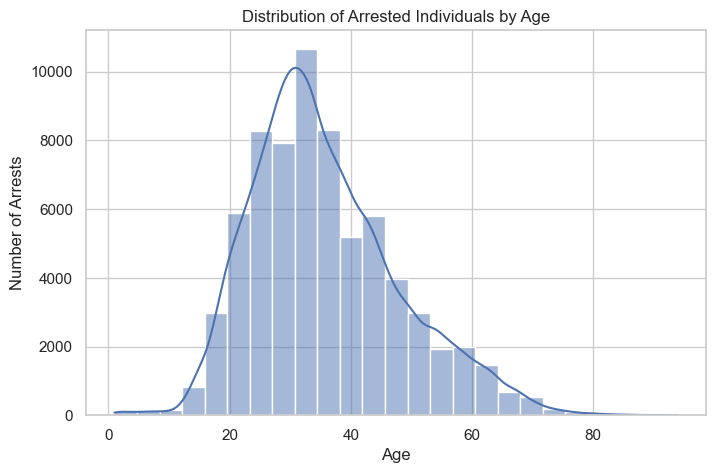

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=25, kde=True)

plt.title("Distribution of Arrested Individuals by Age")
plt.xlabel("Age")
plt.ylabel("Number of Arrests")
plt.show()

Insight

Most arrested individuals belong to the young and middle-aged population, while arrests involving elderly individuals are relatively uncommon.

# 2. Arrests by Gender (Bar Chart)

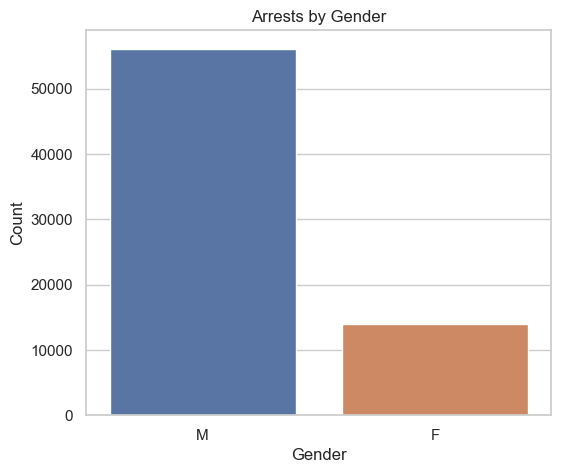

In [62]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Sex_Code')

plt.title("Arrests by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Insight

Male individuals account for the majority of arrests, indicating a significant gender imbalance in arrest records.

# 3. Top 10 Areas with Highest Arrests

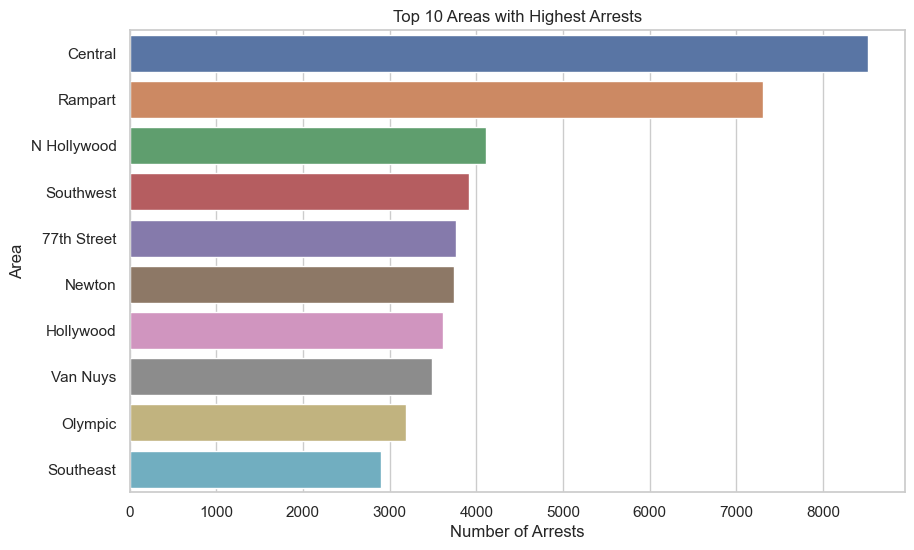

In [63]:
top_area = df['Area_Name'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_area.values,
            y=top_area.index)

plt.title("Top 10 Areas with Highest Arrests")
plt.xlabel("Number of Arrests")
plt.ylabel("Area")
plt.show()

Insight

A few areas have much higher arrest counts than the rest, suggesting these locations may experience more criminal activity or stronger policing efforts

# 4. Monthly Arrest Trend (Line Chart)

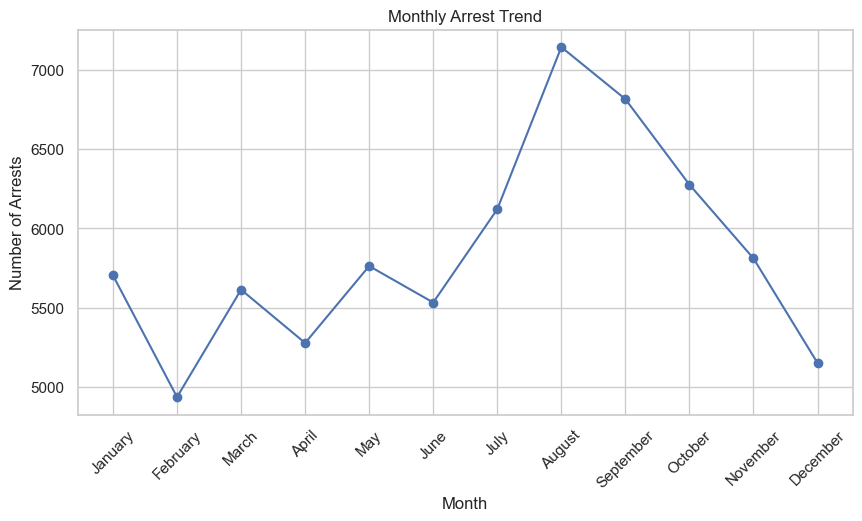

In [64]:
monthly = df.groupby('Arrest_Month').size()

plt.figure(figsize=(10,5))

plt.plot(monthly.index,
         monthly.values,
         marker='o')

plt.title("Monthly Arrest Trend")
plt.xlabel("Month")
plt.ylabel("Number of Arrests")

plt.xticks(rotation=45)

plt.show()

Insight

Arrests were highest during August and September, while February recorded comparatively fewer arrests. This suggests that arrest activity changes throughout the year rather than remaining constant.

# 5. Arrests by Hour

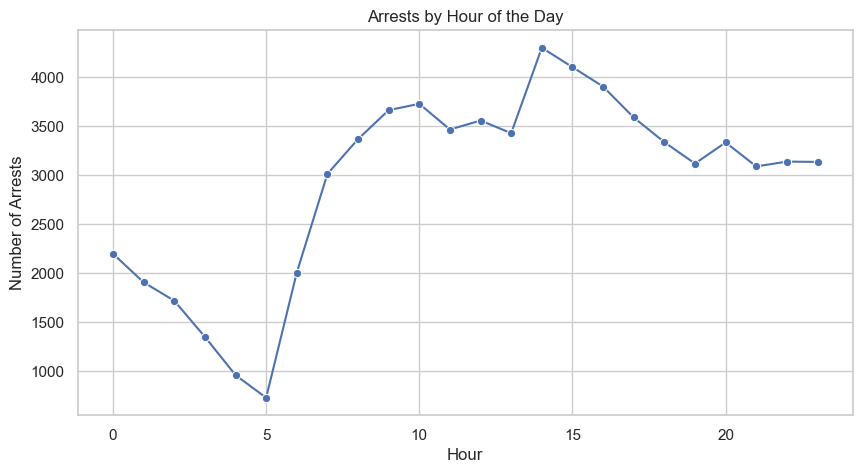

In [65]:
hourly = df.groupby('Arrest_Hour').size()

plt.figure(figsize=(10,5))

sns.lineplot(x=hourly.index,
             y=hourly.values,
             marker='o')

plt.title("Arrests by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Arrests")

plt.show()

Insight

Arrest frequency varies throughout the day, helping identify peak hours of police activity.

# 6. Top 10 Charge Categories

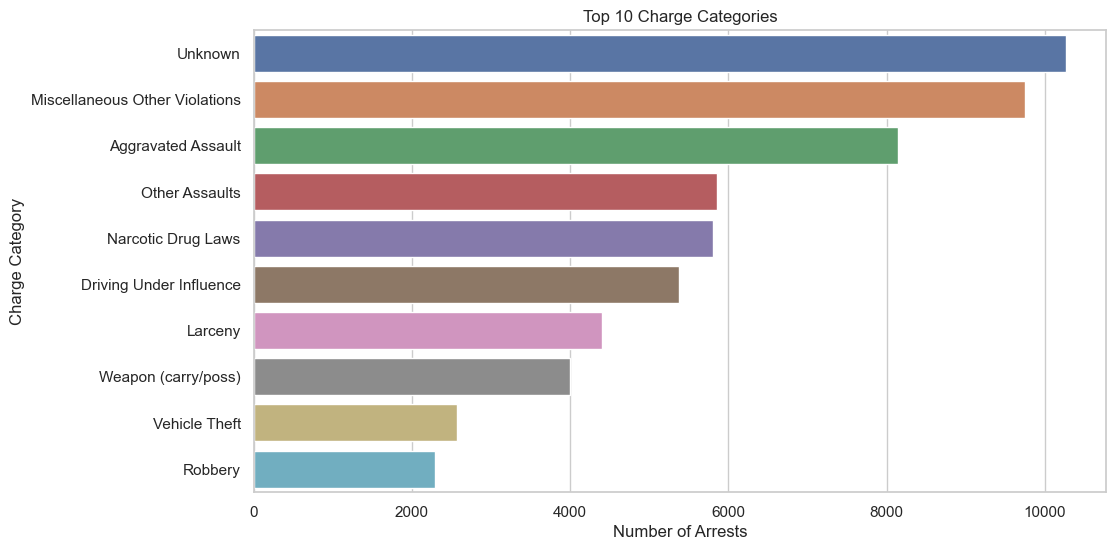

In [66]:
charges = df['Charge_Group_Description'].value_counts().head(10)

plt.figure(figsize=(11,6))

sns.barplot(
    x=charges.values,
    y=charges.index
)

plt.title("Top 10 Charge Categories")
plt.xlabel("Number of Arrests")
plt.ylabel("Charge Category")

plt.show()

Insight

A small number of charge categories account for a large proportion of arrests, with miscellaneous violations and assault-related offenses among the most common.

# 7. Boxplot of Age by Gender

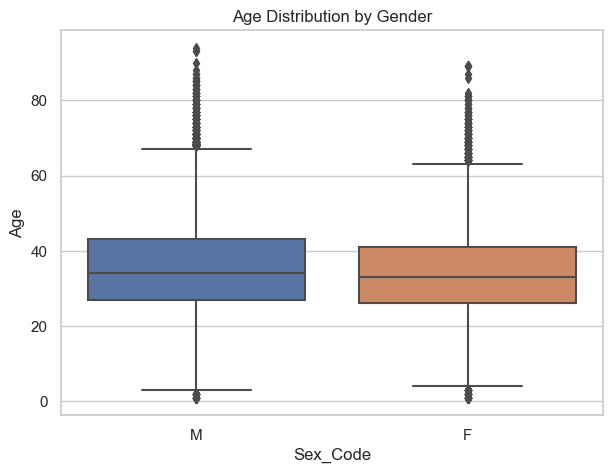

In [67]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Sex_Code',
    y='Age'
)

plt.title("Age Distribution by Gender")

plt.show()

Insight

The age distribution differs slightly across genders, and the boxplot highlights the presence of outliers among older individuals.

# 8. Correlation Heatmap

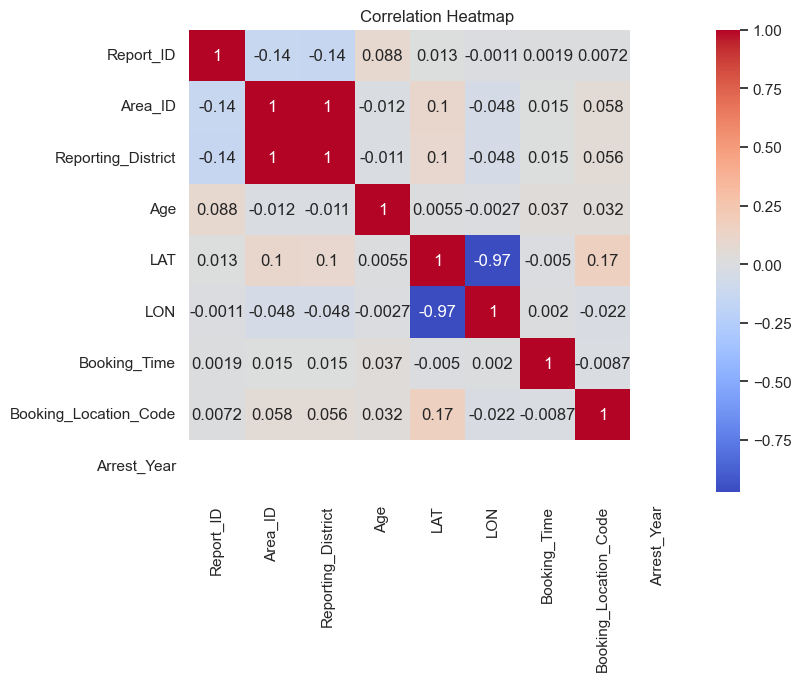

In [68]:
num_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Insight

Most numerical variables show weak correlations, suggesting that factors such as age, reporting district, and geographic coordinates are largely independent.

# 9. Arrest Locations (Scatter Plot)

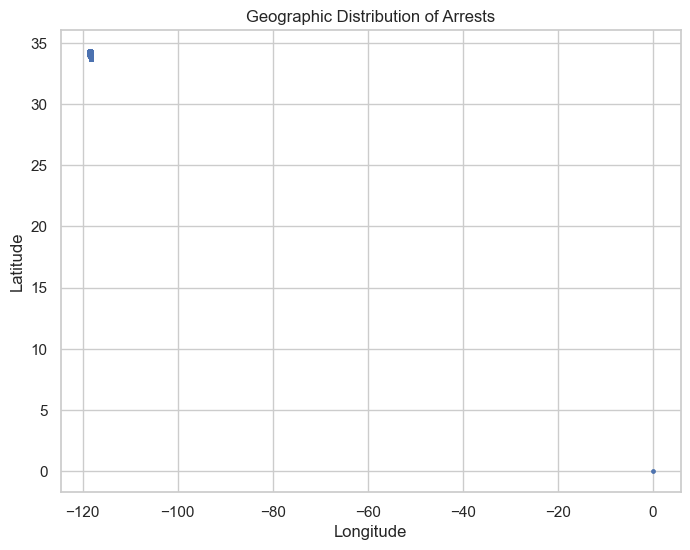

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['LON'],
    df['LAT'],
    alpha=0.3,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Geographic Distribution of Arrests")

plt.show()

Insight

Arrests are concentrated in specific geographic regions rather than being uniformly distributed across the city.

# 10. Arrest Type Distribution (Pie Chart)

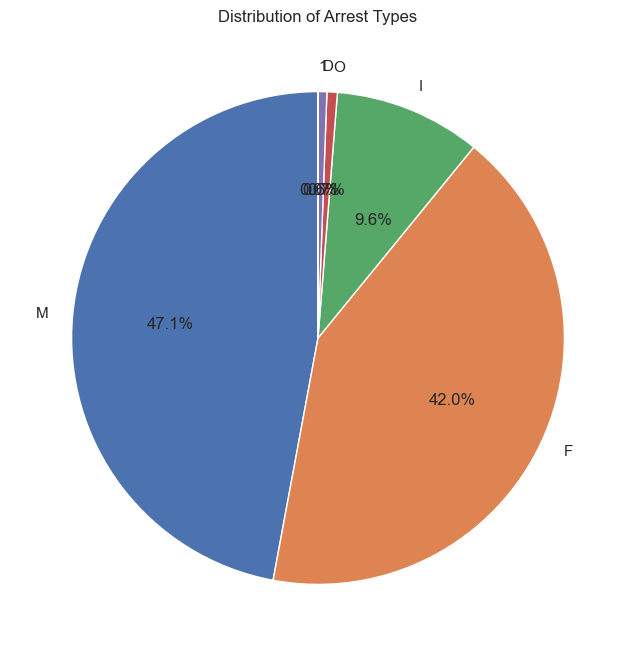

In [70]:
arrest_type = df['Arrest_Type_Code'].value_counts()

fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    arrest_type,
    labels=arrest_type.index,
    autopct='%1.1f%%',
    startangle=90
)

# Move the third percentage slightly downward
x, y = autotexts[2].get_position()
autotexts[2].set_position((x, y - 0.08))

plt.title("Distribution of Arrest Types")
plt.show()

Insight

One arrest type constitutes the majority of records, indicating that certain law enforcement procedures occur much more frequently than others.

# 11. Top 10 Areas by Average Age

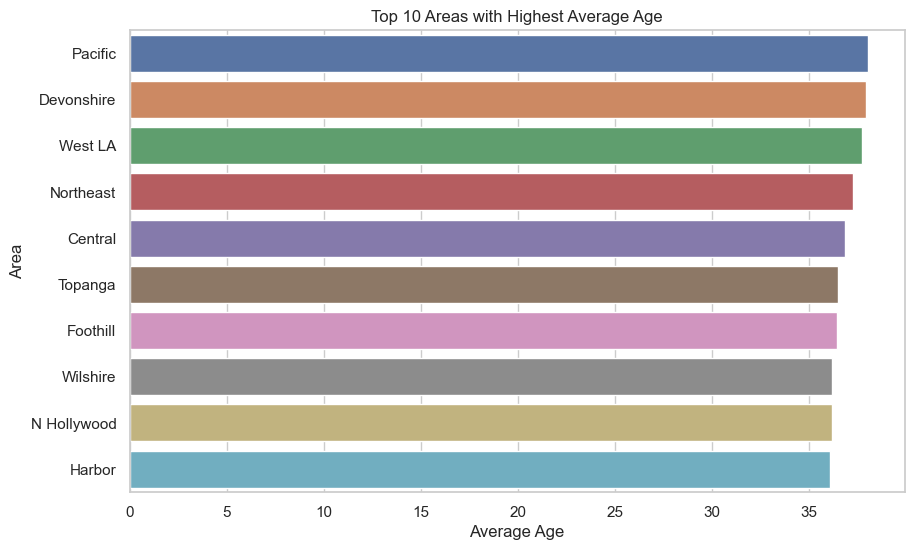

In [71]:
avg_age = (
    df.groupby('Area_Name')['Age']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_age.values,
    y=avg_age.index
)

plt.title("Top 10 Areas with Highest Average Age")
plt.xlabel("Average Age")
plt.ylabel("Area")

plt.show()

Insight

Some police divisions report a higher average age among arrested individuals, suggesting differences in the demographic profile of arrests across areas.

# Project insights



1. Male individuals account for the majority of arrest records, indicating a clear gender imbalance.
2. A small number of police divisions contribute a disproportionately high share of arrests, suggesting localized crime hotspots or greater enforcement.
3. Arrests peak during specific hours of the day, revealing temporal patterns in law enforcement activity.
4. Miscellaneous violations and assault-related offenses are among the most frequent charge categories, making them key contributors to overall arrest volume.
5. Arrest records are geographically clustered rather than evenly distributed, indicating that criminal activity and enforcement are concentrated in specific locations.
